In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# SECTION 1: DATA UNDERSTANDING

In [ ]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("Shape:", df.shape,"\n")
print("Columns:")
print(df.columns,"\n")

print("Missing Values:")
print(df.isnull().sum(),"\n")

print("Data Types:","\n")
print(df.dtypes,"\n")

Shape: (200, 5) 

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object') 

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64 

Data Types: 

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object 



What type of dataset is this?

*   Structured dataset
*   Customer demographic and spending data
*   Contains numerical and categorical variables

Numerical Features

*   Age
*   Annual Income
*   Spending Score

Categorical Features
* Gender




## SECTION 2: DESCRIPTIVE ANALYSIS

In [ ]:
#DESCRIPTIVE ANALYSIS
features = ['Age',
            'Annual Income (k$)',
            'Spending Score (1-100)']

for i in features:
    print("\n", i)
    print("Mean =", df[i].mean())
    print("Median =", df[i].median())
    print("Std Dev =", df[i].std(),"\n\n")
print("Highest Variability:")
df[features].std()


 Age
Mean = 38.85
Median = 36.0
Std Dev = 13.969007331558883 



 Annual Income (k$)
Mean = 60.56
Median = 61.5
Std Dev = 26.264721165271254 



 Spending Score (1-100)
Mean = 50.2
Median = 50.0
Std Dev = 25.823521668370162 


Highest Variability:


,0
Age,13.969007
Annual Income (k$),26.264721
Spending Score (1-100),25.823522




*   Feature with highest standard deviation has highest variability.
*  Large standard deviation indicates diverse customers.
*   Small standard deviation indicates similar customers.








## SECTION 3: VISUALIZATION

Histogram:



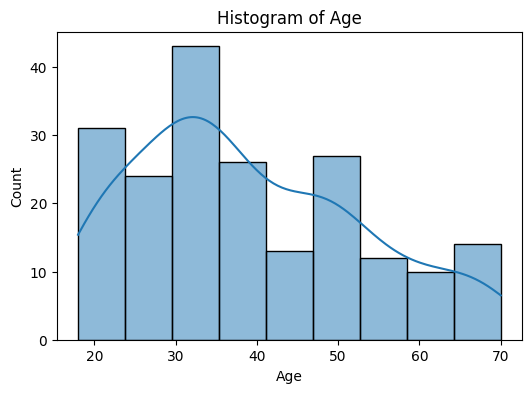

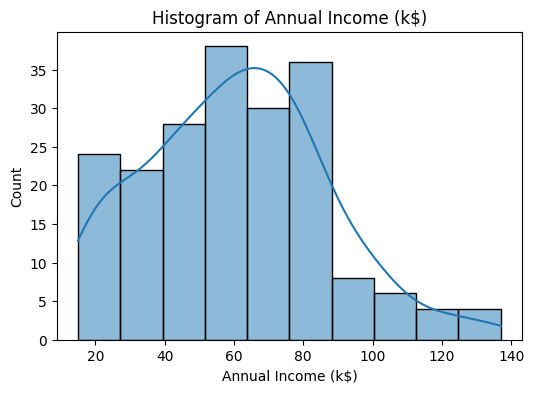

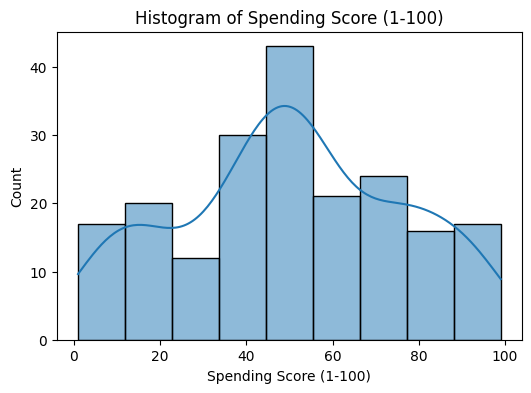

In [ ]:
print("Histogram:\n")
for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

Boxplot:



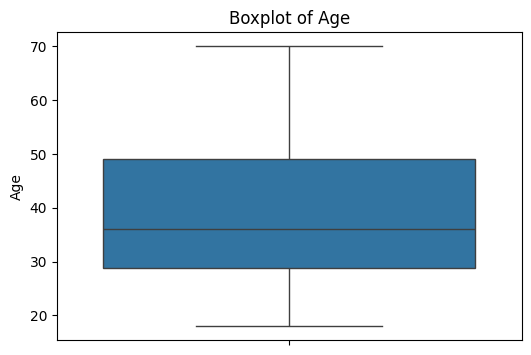

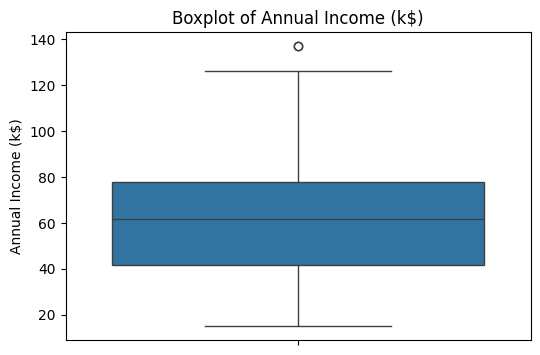

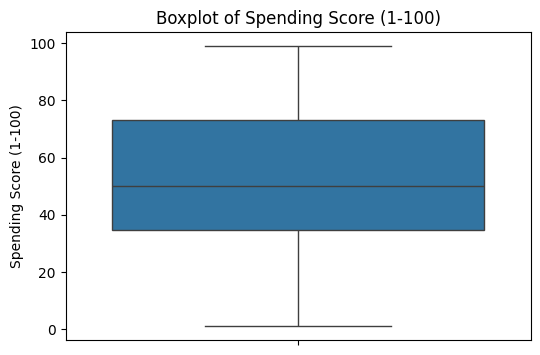

In [ ]:
print("Boxplot:\n")
for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Look for:

Right skew implies tail on right side

Left skew implies tail on left side

Outliers implies points beyond whiskers

## SECTION 4: GROUP ANALYSIS

In [ ]:
gender_stats = df.groupby('Gender')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print(gender_stats)

        Annual Income (k$)  Spending Score (1-100)
Gender                                            
Female           59.250000               51.526786
Male             62.227273               48.511364


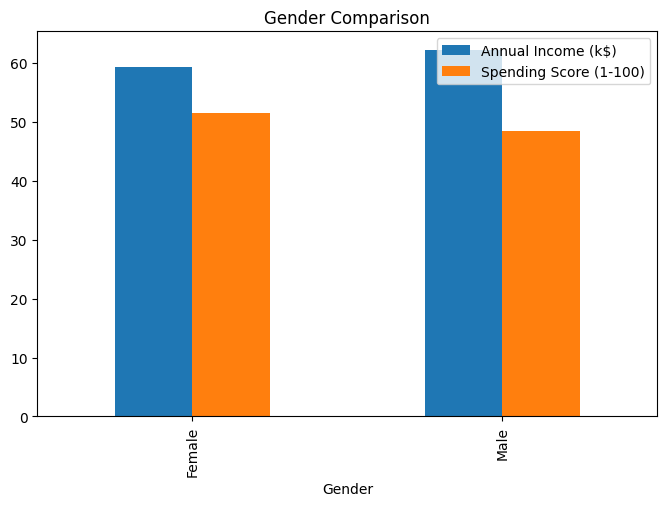

In [ ]:
gender_stats.plot(kind='bar', figsize=(8,5))
plt.title("Gender Comparison")
plt.show()

Compare average spending scores.

Compare average income.

State which gender spends more.

## SECTION 5 : CORRELATION ANALYSIS

In [ ]:
import pandas as pd
df=pd.read_csv("Mall_Customers.csv")

corr = df[['Age',
'Annual Income (k$)',
'Spending Score (1-100)']].corr()

print(corr)

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


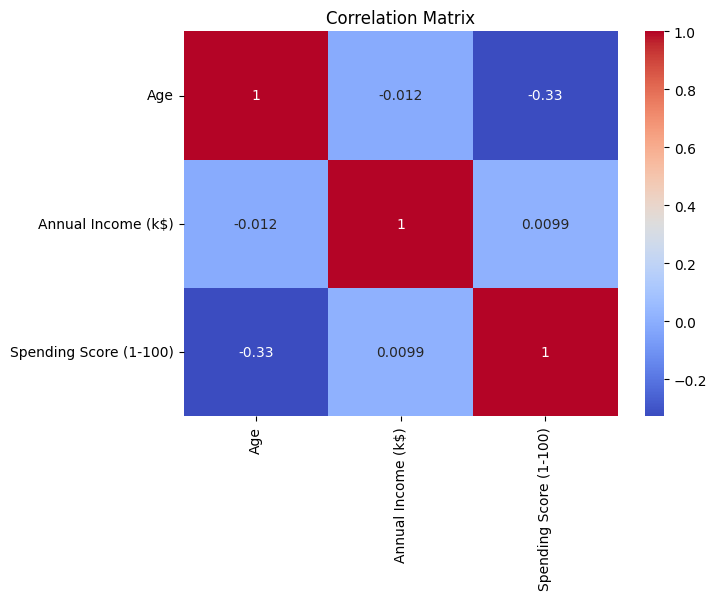

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [ ]:
#Do richer customers spend more?
corr.loc['Annual Income (k$)',
         'Spending Score (1-100)']

np.float64(0.009902848094037497)

In [ ]:
#Does age affect spending?
corr.loc['Age',
         'Spending Score (1-100)']

np.float64(-0.32722684603909025)

##SECTION 6: INFERENTIAL STATISTICS (CORE)

Hypothesis
Null Hypothesis (H₀):

Male and female customers spend equally.

Alternative Hypothesis (H₁):

Male and female customers spend differently.

In [ ]:
from scipy import stats
#T-Test
male = df[df['Gender']=='Male']['Spending Score (1-100)']

female = df[df['Gender']=='Female']['Spending Score (1-100)']

t_stat, p_value = stats.ttest_ind(male, female)

print("T Statistic =", t_stat)
print("P Value =", p_value)

T Statistic = -0.8190464150660334
P Value = 0.4137446589852174


In [ ]:
#Decision
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")
#Interpretation
#p-value < 0.05 , significant difference
#p-value > 0.05 , no significant difference

Fail to Reject H0


##SECTION 7: CONFIDENCE INTERVAL

In [ ]:
#95% Confidence Interval
scores = df['Spending Score (1-100)']

mean = scores.mean()

std_error = stats.sem(scores)

ci = stats.t.interval(
    confidence=0.95,
    df=len(scores)-1,
    loc=mean,
    scale=std_error
)

print("95% Confidence Interval:")
print(ci)

95% Confidence Interval:
(np.float64(46.5992098573812), np.float64(53.80079014261881))


In [ ]:
#Interpretation
#Example:
#(47.1 , 54.8)
#Means:
#"We are 95% confident that the true average spending score lies between 47.1 and 54.8."

##SECTION 8: BUSINESS INSIGHTS
1. Which customers should the business target?

Customers with high spending scores.
High-income customers who spend frequently.
Young adults with strong purchasing behavior.

2. Does income affect spending?

Use correlation results.
If correlation is weak, income alone should not be used for targeting.
If strong, prioritize high-income groups.

3. Should marketing differ by gender?

Use t-test result.
Significant difference → customized campaigns.
No significant difference → same marketing strategy.

4. Suggested Strategy
Loyalty rewards for high spenders.

Personalized offers.
Segment customers by spending behavior.
Focus promotions on profitable customer groups.

#REPORT CONCLUSION

The Mall Customer dataset was analyzed using descriptive and inferential statistics. Age, Annual Income, and Spending Score distributions were examined through histograms and boxplots. Correlation analysis showed the relationship among customer attributes, while a two-sample t-test was conducted to compare spending behavior between male and female customers. The statistical results were used to generate actionable business recommendations regarding customer targeting, segmentation, and marketing strategy. The analysis demonstrates how statistical methods support data-driven business decision-making.